In [2]:
# Load packages
import igraph as ig
import numpy as np
import matplotlib.pyplot as plt

# Simulate random graphs according to a fixed number of edges (m) and a fixed number of nodes (n)
n = 50
m_values = [5, 15, 25, 35, 48]
for m in m_values:
    # Erdos-Renyi model with fixed number of edges
    g_er = ig.Graph.Erdos_Renyi(n=n, m=m)

    # Plot and save the graph
    fig, ax = plt.subplots(figsize=(6, 6))
    ig.plot(g_er, target=ax, vertex_size=20, vertex_color='indianred', edge_color='black', layout='fr')
    plt.tight_layout()
    plt.savefig(f'../Slides/Floats/Erdos_Renyi_Edges_n{n}_m{m}.png')
    plt.clf()  # Clear the figure for the next plot

<Figure size 600x600 with 0 Axes>

<Figure size 600x600 with 0 Axes>

<Figure size 600x600 with 0 Axes>

<Figure size 600x600 with 0 Axes>

<Figure size 600x600 with 0 Axes>

In [3]:
# Simulate random graphs according to a fixed probability of edge creation (p) and a fixed number of nodes (n)
N = n * (n - 1) / 2  # Total possible edges in an undirected graph without self-loops
p_values = np.asarray(m_values) / N  # Convert m values to probabilities
for index, p in enumerate(p_values):
    # Erdos-Renyi model with fixed probability of edge creation
    g_er = ig.Graph.Erdos_Renyi(n=n, p=p)

    # Plot and save the graph
    fig, ax = plt.subplots(figsize=(6, 6))
    ig.plot(g_er, target=ax, vertex_size=20, vertex_color='indianred', edge_color='black', layout='fr')
    plt.tight_layout()
    plt.savefig(f'../Slides/Floats/Erdos_Renyi_Probability_n{n}_p{m_values[index]}.png')
    plt.clf()  # Clear the figure for the next plot

<Figure size 600x600 with 0 Axes>

<Figure size 600x600 with 0 Axes>

<Figure size 600x600 with 0 Axes>

<Figure size 600x600 with 0 Axes>

<Figure size 600x600 with 0 Axes>

In [4]:
# Solve for p that corresponds to a specific number of edges (m) in the Erdos-Renyi model
from scipy import optimize, special
import sympy as sp
n = 3
m = 1
N = n * (n - 1) / 2  # Total possible edges in an undirected graph without self-loops

def objective(p):
    return p**m * (1 - p)**(N - m)

def rational_objective(p):
    return sp.Rational(p**m * (1 - p)**(N - m))

def difference(p):
    return (objective(p) - 1/special.comb(N, m))**2

result = optimize.minimize_scalar(difference, bounds=(0, 1), method='bounded')
p_optimal = result.x
print(f"Optimal probability p for n={n} and m={m}: {p_optimal:.4f}")
print("Value and difference at optimal p:", objective(p_optimal), difference(p_optimal))
print("Expected number of edges for n=3 and p_optimal:", p_optimal * N)

# Symbolic evaluation of objective function at specific values of p
p_values = [sp.Rational(0), sp.Rational(1, 3), sp.Rational(1, 2), sp.Rational(2, 3), sp.Rational(1)]
objective_values = [objective(p) for p in p_values]
print("p values and corresponding objective function values:", list(zip(p_values, objective_values)))

Optimal probability p for n=3 and m=1: 0.3333
Value and difference at optimal p: 0.1481481481479932 0.03429355281212871
Expected number of edges for n=3 and p_optimal: 1.0000011809062155
p values and corresponding objective function values: [(0, 0), (1/3, 0.148148148148148), (1/2, 0.125000000000000), (2/3, 0.0740740740740741), (1, 0)]


Total number of networks with n=3: 8
Expected: 2^3 = 2^3 = 8



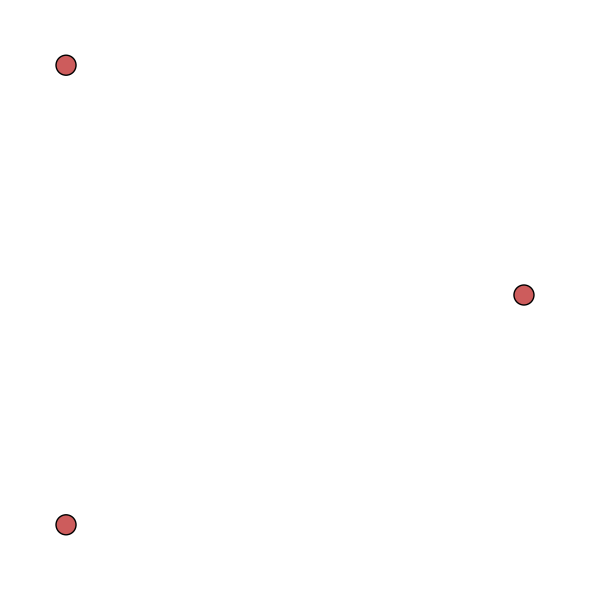

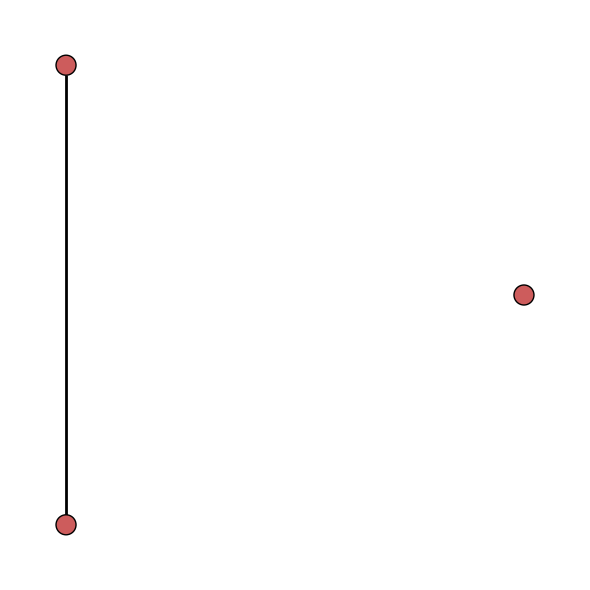

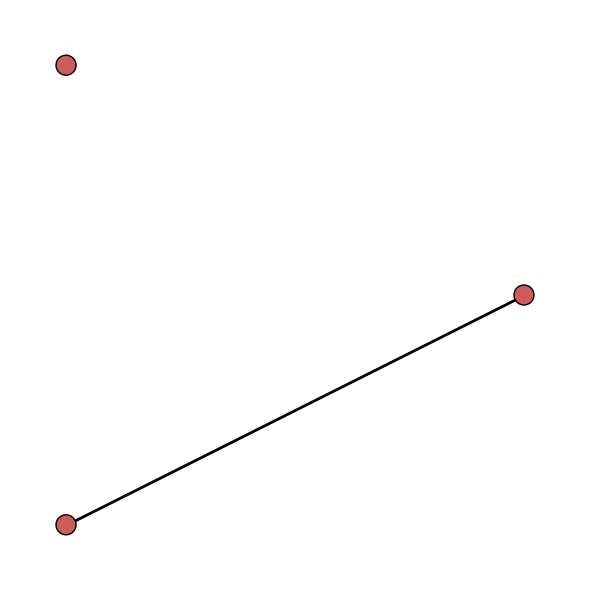

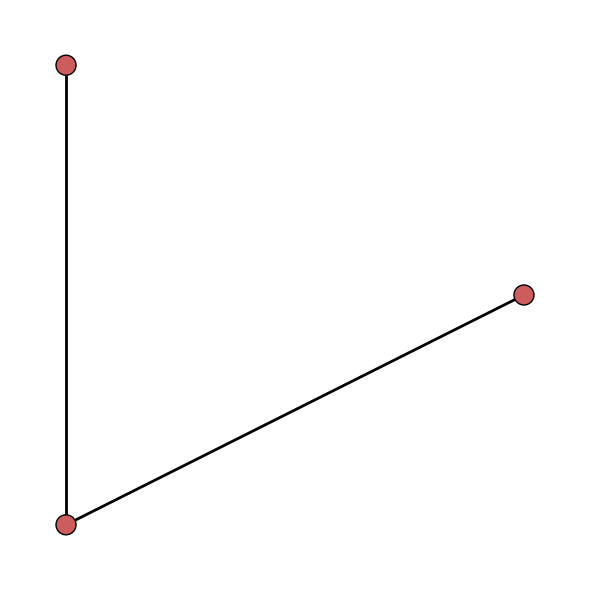

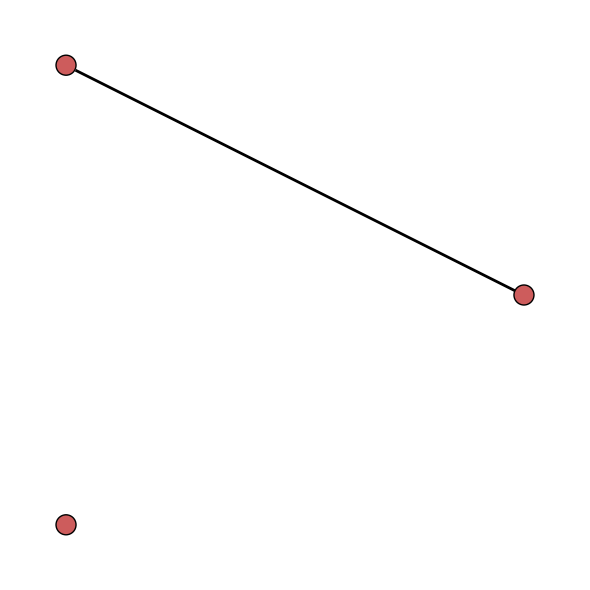

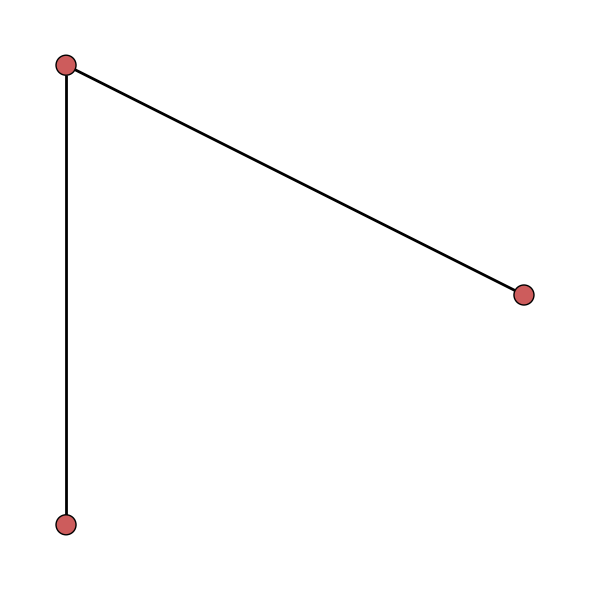

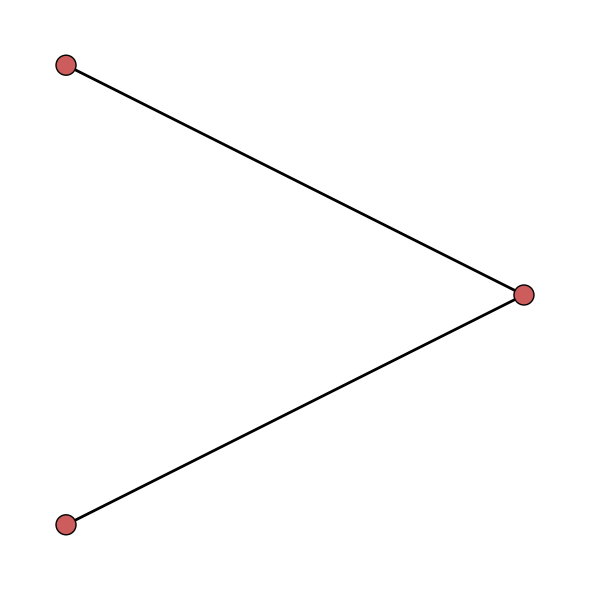

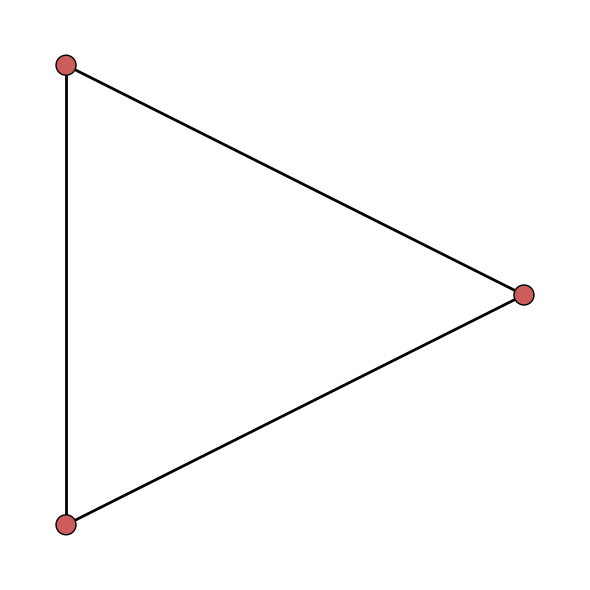

In [5]:
# Generate all networks with n=3
import itertools

# Generate all possible undirected networks with n nodes.
# 
# For n nodes, there are n(n-1)/2 possible edges.
# Each edge can be present (1) or absent (0).
# Total networks: 2^(n(n-1)/2)
n = 3
num_edges = n * (n - 1) // 2
all_networks = []

# Iterate over all possible edge configurations
counter = 1
for edge_config in itertools.product([0, 1], repeat=num_edges):
    # Create adjacency matrix
    A = np.zeros((n, n), dtype=int)
    
    # Fill upper triangle with edge configuration
    edge_idx = 0
    for i in range(n):
        for j in range(i + 1, n):
            A[i, j] = edge_config[edge_idx]
            A[j, i] = edge_config[edge_idx]  # Symmetric for undirected
            edge_idx += 1
    
    all_networks.append(A)

    # Plot and visualize the network
    g = ig.Graph.Adjacency(A.tolist(), mode=ig.ADJ_UNDIRECTED)
    fig, ax = plt.subplots(figsize=(6, 6))
    ig.plot(g, target=ax, vertex_size=20, vertex_color='indianred', edge_color='black', layout='circle')
    plt.tight_layout()
    plt.savefig(f'../Slides/Floats/All_n{n}_{counter}.png')
    counter += 1

print(f"Total number of networks with n=3: {len(all_networks)}")
print(f"Expected: 2^{3*2//2} = 2^3 = 8\n")

In [6]:
# Simulate phase transitions by plotting behaviour for large n with given p values
n = 50
N = n * (n - 1) / 2  # Total possible edges in an undirected graph without self-loops
p_values = np.array([.0004, .003, .01, .02, .03, .05, .08, .1])
for index, p in enumerate(p_values):
    # Erdos-Renyi model with fixed probability of edge creation
    g_er = ig.Graph.Erdos_Renyi(n=n, p=p)

    # Plot and save the graph
    fig, ax = plt.subplots(figsize=(6, 6))
    ig.plot(g_er, target=ax, vertex_size=20, vertex_color='indianred', edge_color='black', layout='fr')
    plt.tight_layout()
    plt.savefig(f'../Slides/Floats/Large_Graphs_p{np.round(p, 4)}.png')
    plt.clf()  # Clear the figure for the next plot

<Figure size 600x600 with 0 Axes>

<Figure size 600x600 with 0 Axes>

<Figure size 600x600 with 0 Axes>

<Figure size 600x600 with 0 Axes>

<Figure size 600x600 with 0 Axes>

<Figure size 600x600 with 0 Axes>

<Figure size 600x600 with 0 Axes>

<Figure size 600x600 with 0 Axes>

In [16]:
# Simulate phase transitions by plotting behaviour from configuration model similar to ER from large n with given p values
n = 50
N = n * (n - 1) / 2  # Total possible edges in an undirected graph without self-loops
p_values = np.array([.0002, .0003, .0005, .001, .002, .003, .005, .01])
rng = np.random.default_rng(seed=123456789)  # Set seed for reproducibility
for index, p in enumerate(p_values):
    # Draw degree sequence from a Poisson distribution with mean equal to the expected number of edges in the ER model
    lam = p * N  # Expected number of edges
    degrees = np.random.poisson(lam, n)

    # Ensure sum of degrees is even
    if degrees.sum() % 2 != 0:
        degrees[0] += 1
    
    # Sample from configuration model using the degree sequence
    print(degrees)
    g_config = ig.Graph.Degree_Sequence(
        degrees,
        method="configuration"
    )
    
    # Simplify (remove multi-edges and loops)
    g_config = g_config.simplify(multiple=True, loops=True)

    # Plot and save the graph
    fig, ax = plt.subplots(figsize=(6, 6))
    ig.plot(g_config, target=ax, vertex_size=20, vertex_color='indianred', edge_color='black', layout='fr')
    plt.tight_layout()
    plt.savefig(f'../Slides/Floats/Configuration_ER_p{np.round(p, 4)}.png')
    plt.clf()  # Clear the figure for the next plot

[0 1 0 0 0 0 1 1 0 0 0 0 1 0 1 0 0 0 0 0 1 1 0 0 0 0 0 1 1 0 0 1 0 0 0 0 0
 0 0 0 0 1 0 0 0 2 0 1 0 0]
[2 0 0 0 0 1 1 0 0 2 0 0 1 0 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1
 0 2 0 0 1 0 0 0 1 0 1 1 0]
[0 1 1 2 2 0 0 1 0 0 0 3 0 0 0 0 0 0 1 2 0 0 0 1 0 0 1 3 0 0 1 0 0 1 1 0 1
 2 2 0 0 0 0 0 1 0 1 1 0 1]
[1 0 2 2 1 0 1 3 0 0 2 1 0 1 0 3 1 0 1 0 0 1 3 5 3 1 0 2 0 1 2 0 1 2 2 0 1
 1 3 2 0 1 0 0 2 0 2 0 2 2]
[3 4 2 3 5 4 2 0 2 2 5 4 2 2 3 2 2 2 1 3 3 4 0 4 4 3 0 2 1 2 2 2 2 2 5 5 1
 7 3 1 1 3 2 5 2 2 2 2 3 2]
[ 5  2  1  2  4  6  7  4  6  2  2  8  5  4  3  5  3  1  4  4  2  3  5  3
  4  4  4  2  5  2 11  3  7  0  4  5  6  0  7  4  3  3  1  2  2  1  5  6
  6  4]
[ 8  6  9  7  5 13  4  4  4  5 10  6  4  8  8  9  4  9  8  7  7  8  8  9
  8  7  7  9  5  8  6  5  7  9  8  6  4  4  8  6  6  6  6  8  5  5  5  6
  7  5]
[15 17 11 11 18 19 13 18  9 16 13 15  7 13 10 14 11 10 12 16 14 15 15 15
 12 11  9 13  8  8 14  4 18 10 15 11 22 12 21 12 11 16 11 12 11  5  9  5
  7 10]


<Figure size 600x600 with 0 Axes>

<Figure size 600x600 with 0 Axes>

<Figure size 600x600 with 0 Axes>

<Figure size 600x600 with 0 Axes>

<Figure size 600x600 with 0 Axes>

<Figure size 600x600 with 0 Axes>

<Figure size 600x600 with 0 Axes>

<Figure size 600x600 with 0 Axes>